# MVP v0.2.5.5: Corrected Guidance — Full Scale Run

**Date:** 2026-03-13  
**Builds on:** v0.2.5.4 (score_timestep=5 is sweet spot, action_scale 0.0003–0.005 works)

## Goal

Full-scale guidance run with corrected settings:
- `score_timestep=5` (sigma=0.105, comparable to SOPE's 0.113)
- `action_scale ∈ [0.0003, 0.001, 0.005]` (total perturbation = 8–130% of |action|)
- 50 trajectories, T_GEN=60
- Both pos-only and full (with behavior subtraction) guidance
- OPE evaluation against oracle

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Corrected guidance config
SCORE_TIMESTEP = 5

GUIDANCE_CONFIGS = [
    {"action_scale": 0.0,    "ratio": 0.0,  "label": "unguided"},
    # Pos-only (target gradient only)
    {"action_scale": 0.0003, "ratio": 0.0,  "label": "pos_0.0003"},
    {"action_scale": 0.001,  "ratio": 0.0,  "label": "pos_0.001"},
    {"action_scale": 0.005,  "ratio": 0.0,  "label": "pos_0.005"},
    # Full guidance (target - ratio * behavior)
    {"action_scale": 0.0003, "ratio": 0.25, "label": "full_0.0003_r0.25"},
    {"action_scale": 0.001,  "ratio": 0.25, "label": "full_0.001_r0.25"},
    {"action_scale": 0.005,  "ratio": 0.25, "label": "full_0.005_r0.25"},
    {"action_scale": 0.001,  "ratio": 0.5,  "label": "full_0.001_r0.5"},
    {"action_scale": 0.005,  "ratio": 0.5,  "label": "full_0.005_r0.5"},
]

print(f"score_timestep={SCORE_TIMESTEP}, {len(GUIDANCE_CONFIGS)} guidance configs")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, 9 guidance configs
50 trajs, T_GEN=60


In [2]:
# ── Load checkpoint, oracle, target rollouts, expert demos ──
ckpt = load_checkpoint(CKPT_DIR, ckpt_path=Path("last.pth"))
target_algo = build_algo_from_checkpoint(ckpt, device=str(device))

with open(CKPT_DIR / "oracle_50.json", "r") as f:
    oracle_data = json.load(f)
oracle_value = float(oracle_data["mean_return"])
oracle_returns = np.array(oracle_data["returns"])
oracle_sr = float(np.mean(oracle_returns > 0.5))
print(f"Oracle V^pi = {oracle_value:.4f}, SR = {oracle_sr*100:.0f}%")

# Target rollouts
target_data = []
all_states_list, all_actions_list = [], []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

# Expert demos
with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

# Normalization (same as v0.2.5.2 training)
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'robot0_eef_pos', 'robot0_eef_quat', 'object']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[16:55:53] INFO     build_algo_from_checkpoint took 0.55 seconds to execute                           ]8;id=298521;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=600136;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Oracle V^pi = 0.5400, SR = 54%


Loaded 50 target rollouts


Loaded 200 expert demos


In [3]:
# ── Load pre-trained diffuser ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

# ── Target scorer at t=5 ──
target_scorer = RobomimicDiffusionScorer(
    target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
)
print(f"Target scorer: score_timestep={SCORE_TIMESTEP}, sigma={target_scorer.sigma:.4f}")

# ── BC behavior policy ──
class BCGaussian(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
    def forward(self, state):
        h = self.net(state)
        return self.mean_head(h), self.log_std_head(h).clamp(-5, 2)
    def grad_log_prob(self, state, action):
        with torch.no_grad():
            mean, log_std = self.forward(state)
            std = torch.exp(log_std)
            return -(action - mean) / (std ** 2)
    def grad_log_prob_chunk(self, states, actions):
        B, T, _ = states.shape
        return self.grad_log_prob(
            states.reshape(B*T, -1), actions.reshape(B*T, -1)
        ).reshape(B, T, -1)

demo_s = np.concatenate([ep["states"][:-1] for ep in target_data], axis=0)
demo_a = np.concatenate([ep["actions"][:-1] for ep in target_data], axis=0)
bc_behavior = BCGaussian(STATE_DIM, ACTION_DIM).to(device)
bc_opt = torch.optim.Adam(bc_behavior.parameters(), lr=1e-3)
s_t = torch.tensor(demo_s, dtype=torch.float32, device=device)
a_t = torch.tensor(demo_a, dtype=torch.float32, device=device)
bc_behavior.train()
for ep in range(500):
    idx = torch.randint(0, len(s_t), (256,), device=device)
    mean, log_std = bc_behavior(s_t[idx])
    std = torch.exp(log_std)
    nll = (0.5*((a_t[idx]-mean)/std)**2 + log_std + 0.5*math.log(2*math.pi)).sum(-1).mean()
    bc_opt.zero_grad(); nll.backward(); bc_opt.step()
bc_behavior.eval()
print(f"BC behavior trained, NLL={nll.item():.4f}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse
Target scorer: score_timestep=5, sigma=0.1050


BC behavior trained, NLL=-7.7555


In [4]:
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None, behavior_scorer=None,
    action_scale=0.0, ratio=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    use_neg = (behavior_scorer is not None and ratio > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                bg = behavior_scorer.grad_log_prob_chunk(sc, ac) if use_neg else None
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                    if bg is not None:
                        bg = bg / (bg.norm(dim=-1, keepdim=True) + 1e-6)
                ga = tg - ratio * bg if use_neg else tg
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = ga
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, :n_store]
        total += n_store
        if total >= t_gen:
            break
        conditions = {0: x[:, -1, :state_dim]}

    return all_traj.detach().cpu().numpy()

print("Generator ready.")

Generator ready.


In [5]:
# ── Build real trajectory reference ──
N_COMPARE = min(NUM_SYNTHETIC, len(target_data))
real_trajs = []
for ep in target_data[:N_COMPARE]:
    traj = np.concatenate([ep["states"][:-1], ep["actions"][:-1]], axis=-1)
    T = len(traj)
    if T >= T_GEN:
        real_trajs.append(traj[:T_GEN])
    else:
        p = np.zeros((T_GEN, TRANSITION_DIM), dtype=np.float32)
        p[:T] = traj; p[T:] = traj[-1]
        real_trajs.append(p)
real_trajs = np.array(real_trajs)
real_states = real_trajs[:, :, :STATE_DIM]

initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:N_COMPARE]]),
    dtype=torch.float32, device=device
)

target_sr_real = np.mean([np.any(real_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                          for j in range(N_COMPARE)])
print(f"Paired comparison: {N_COMPARE} trajs, T_GEN={T_GEN}")
print(f"Real target SR (from recorded data): {target_sr_real*100:.0f}% (known bug: should be ~{oracle_sr*100:.0f}%)")

Paired comparison: 50 trajs, T_GEN=60
Real target SR (from recorded data): 0% (known bug: should be ~54%)


In [6]:
# ── Guidance sweep ──
np.random.seed(42)
torch.manual_seed(42)

results = {}
t0_all = time.time()

for i, gc in enumerate(GUIDANCE_CONFIGS):
    label = gc["label"]
    asc = gc["action_scale"]
    ratio = gc["ratio"]
    is_unguided = (asc == 0.0)
    
    print(f"[{i+1}/{len(GUIDANCE_CONFIGS)}] {label} ", end="", flush=True)
    t0 = time.time()
    
    trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer if not is_unguided else None,
        behavior_scorer=bc_behavior if (not is_unguided and ratio > 0) else None,
        action_scale=asc, ratio=ratio, normalize_grad=True,
    )
    elapsed = time.time() - t0
    
    ss = trajs[:, :, :STATE_DIM]
    sa = trajs[:, :, STATE_DIM:]
    
    state_mse = np.mean((real_states - ss) ** 2)
    per_step_mse = np.mean((real_states - ss) ** 2, axis=(0, 2))
    synth_sr = np.mean([np.any(ss[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD) for j in range(N_COMPARE)])
    
    # OPE: reward = 1 if any cube_z > 0.84, else 0 (gamma=1)
    synth_returns = np.array([float(np.any(ss[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)) for j in range(N_COMPARE)])
    ope_estimate = np.mean(synth_returns)
    ope_std = np.std(synth_returns) / np.sqrt(N_COMPARE)
    ope_mse = (ope_estimate - oracle_value) ** 2
    ope_rel_err = abs(ope_estimate - oracle_value) / (oracle_value + 1e-8)
    
    results[label] = {
        "action_scale": asc, "ratio": ratio,
        "state_mse": state_mse, "state_rmse": np.sqrt(state_mse),
        "synth_sr": synth_sr,
        "ope_estimate": ope_estimate, "ope_std": ope_std,
        "ope_mse": ope_mse, "ope_rel_err": ope_rel_err,
        "per_step_mse": per_step_mse,
        "synth_states": ss, "synth_returns": synth_returns,
        "time": elapsed,
    }
    
    print(f"SR={synth_sr*100:.0f}%, MSE={state_mse:.5f}, "
          f"OPE={ope_estimate:.3f} (err={ope_rel_err*100:.1f}%), {elapsed:.0f}s")

total_time = time.time() - t0_all
print(f"\nTotal sweep time: {total_time:.0f}s ({total_time/60:.1f} min)")

[1/9] unguided 

SR=60%, MSE=0.00673, OPE=0.600 (err=11.1%), 63s
[2/9] pos_0.0003 

SR=58%, MSE=0.00697, OPE=0.580 (err=7.4%), 120s
[3/9] pos_0.001 

SR=60%, MSE=0.00592, OPE=0.600 (err=11.1%), 119s
[4/9] pos_0.005 

SR=60%, MSE=0.00637, OPE=0.600 (err=11.1%), 119s
[5/9] full_0.0003_r0.25 

SR=68%, MSE=0.00589, OPE=0.680 (err=25.9%), 120s
[6/9] full_0.001_r0.25 

SR=68%, MSE=0.00667, OPE=0.680 (err=25.9%), 120s
[7/9] full_0.005_r0.25 

SR=62%, MSE=0.00546, OPE=0.620 (err=14.8%), 120s
[8/9] full_0.001_r0.5 

SR=62%, MSE=0.00570, OPE=0.620 (err=14.8%), 120s
[9/9] full_0.005_r0.5 

SR=58%, MSE=0.00548, OPE=0.580 (err=7.4%), 120s

Total sweep time: 1023s (17.0 min)


In [7]:
# ── Summary table ──
print(f"{'='*90}")
print(f"v0.2.5.5 GUIDANCE SWEEP — score_timestep={SCORE_TIMESTEP}, sigma={target_scorer.sigma:.4f}")
print(f"{'='*90}")
print(f"Oracle V^pi = {oracle_value:.4f}, Oracle SR = {oracle_sr*100:.0f}%")
print(f"\n{'Config':<22} {'Scale':>7} {'Ratio':>6} {'SR':>5} {'MSE':>9} "
      f"{'OPE':>6} {'RelErr':>7} {'OPE±':>6}")
print("-" * 80)
for label, r in results.items():
    print(f"{label:<22} {r['action_scale']:>7.4f} {r['ratio']:>6.2f} "
          f"{r['synth_sr']*100:>4.0f}% {r['state_mse']:>9.5f} "
          f"{r['ope_estimate']:>6.3f} {r['ope_rel_err']*100:>6.1f}% "
          f"±{r['ope_std']:>.3f}")

# Best configs
best_ope = min(results, key=lambda l: results[l]["ope_rel_err"])
best_mse = min(results, key=lambda l: results[l]["state_mse"])
print(f"\nBest OPE: {best_ope} (err={results[best_ope]['ope_rel_err']*100:.1f}%, SR={results[best_ope]['synth_sr']*100:.0f}%)")
print(f"Best MSE: {best_mse} (MSE={results[best_mse]['state_mse']:.5f}, SR={results[best_mse]['synth_sr']*100:.0f}%)")

v0.2.5.5 GUIDANCE SWEEP — score_timestep=5, sigma=0.1050
Oracle V^pi = 0.5400, Oracle SR = 54%

Config                   Scale  Ratio    SR       MSE    OPE  RelErr   OPE±
--------------------------------------------------------------------------------
unguided                0.0000   0.00   60%   0.00673  0.600   11.1% ±0.069
pos_0.0003              0.0003   0.00   58%   0.00697  0.580    7.4% ±0.070
pos_0.001               0.0010   0.00   60%   0.00592  0.600   11.1% ±0.069
pos_0.005               0.0050   0.00   60%   0.00637  0.600   11.1% ±0.069
full_0.0003_r0.25       0.0003   0.25   68%   0.00589  0.680   25.9% ±0.066
full_0.001_r0.25        0.0010   0.25   68%   0.00667  0.680   25.9% ±0.066
full_0.005_r0.25        0.0050   0.25   62%   0.00546  0.620   14.8% ±0.069
full_0.001_r0.5         0.0010   0.50   62%   0.00570  0.620   14.8% ±0.069
full_0.005_r0.5         0.0050   0.50   58%   0.00548  0.580    7.4% ±0.070

Best OPE: pos_0.0003 (err=7.4%, SR=58%)
Best MSE: full_0.005_r

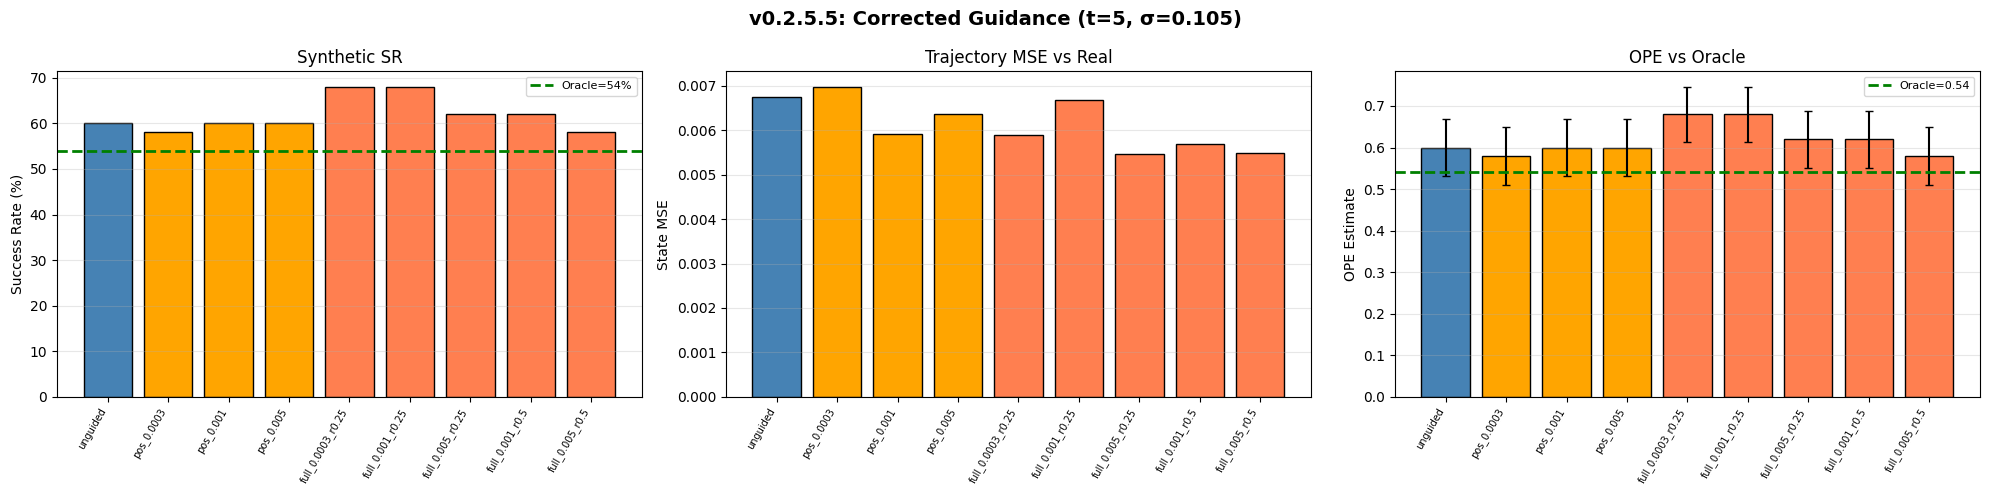

In [8]:
# ── Figure 1: Overview (SR, MSE, OPE) ──
labels = list(results.keys())
srs = [results[l]["synth_sr"]*100 for l in labels]
mses = [results[l]["state_mse"] for l in labels]
opes = [results[l]["ope_estimate"] for l in labels]
ope_stds = [results[l]["ope_std"] for l in labels]

colors = []
for l in labels:
    if "unguided" in l: colors.append("steelblue")
    elif "full" in l: colors.append("coral")
    else: colors.append("orange")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].bar(range(len(labels)), srs, color=colors, edgecolor="black")
axes[0].axhline(y=oracle_sr*100, color="green", linestyle="--", lw=2, label=f"Oracle={oracle_sr*100:.0f}%")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_title("Synthetic SR")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(range(len(labels)), mses, color=colors, edgecolor="black")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[1].set_ylabel("State MSE")
axes[1].set_title("Trajectory MSE vs Real")
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(range(len(labels)), opes, yerr=ope_stds, color=colors, edgecolor="black", capsize=3)
axes[2].axhline(y=oracle_value, color="green", linestyle="--", lw=2, label=f"Oracle={oracle_value:.2f}")
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[2].set_ylabel("OPE Estimate")
axes[2].set_title("OPE vs Oracle")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"v0.2.5.5: Corrected Guidance (t={SCORE_TIMESTEP}, σ={target_scorer.sigma:.3f})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

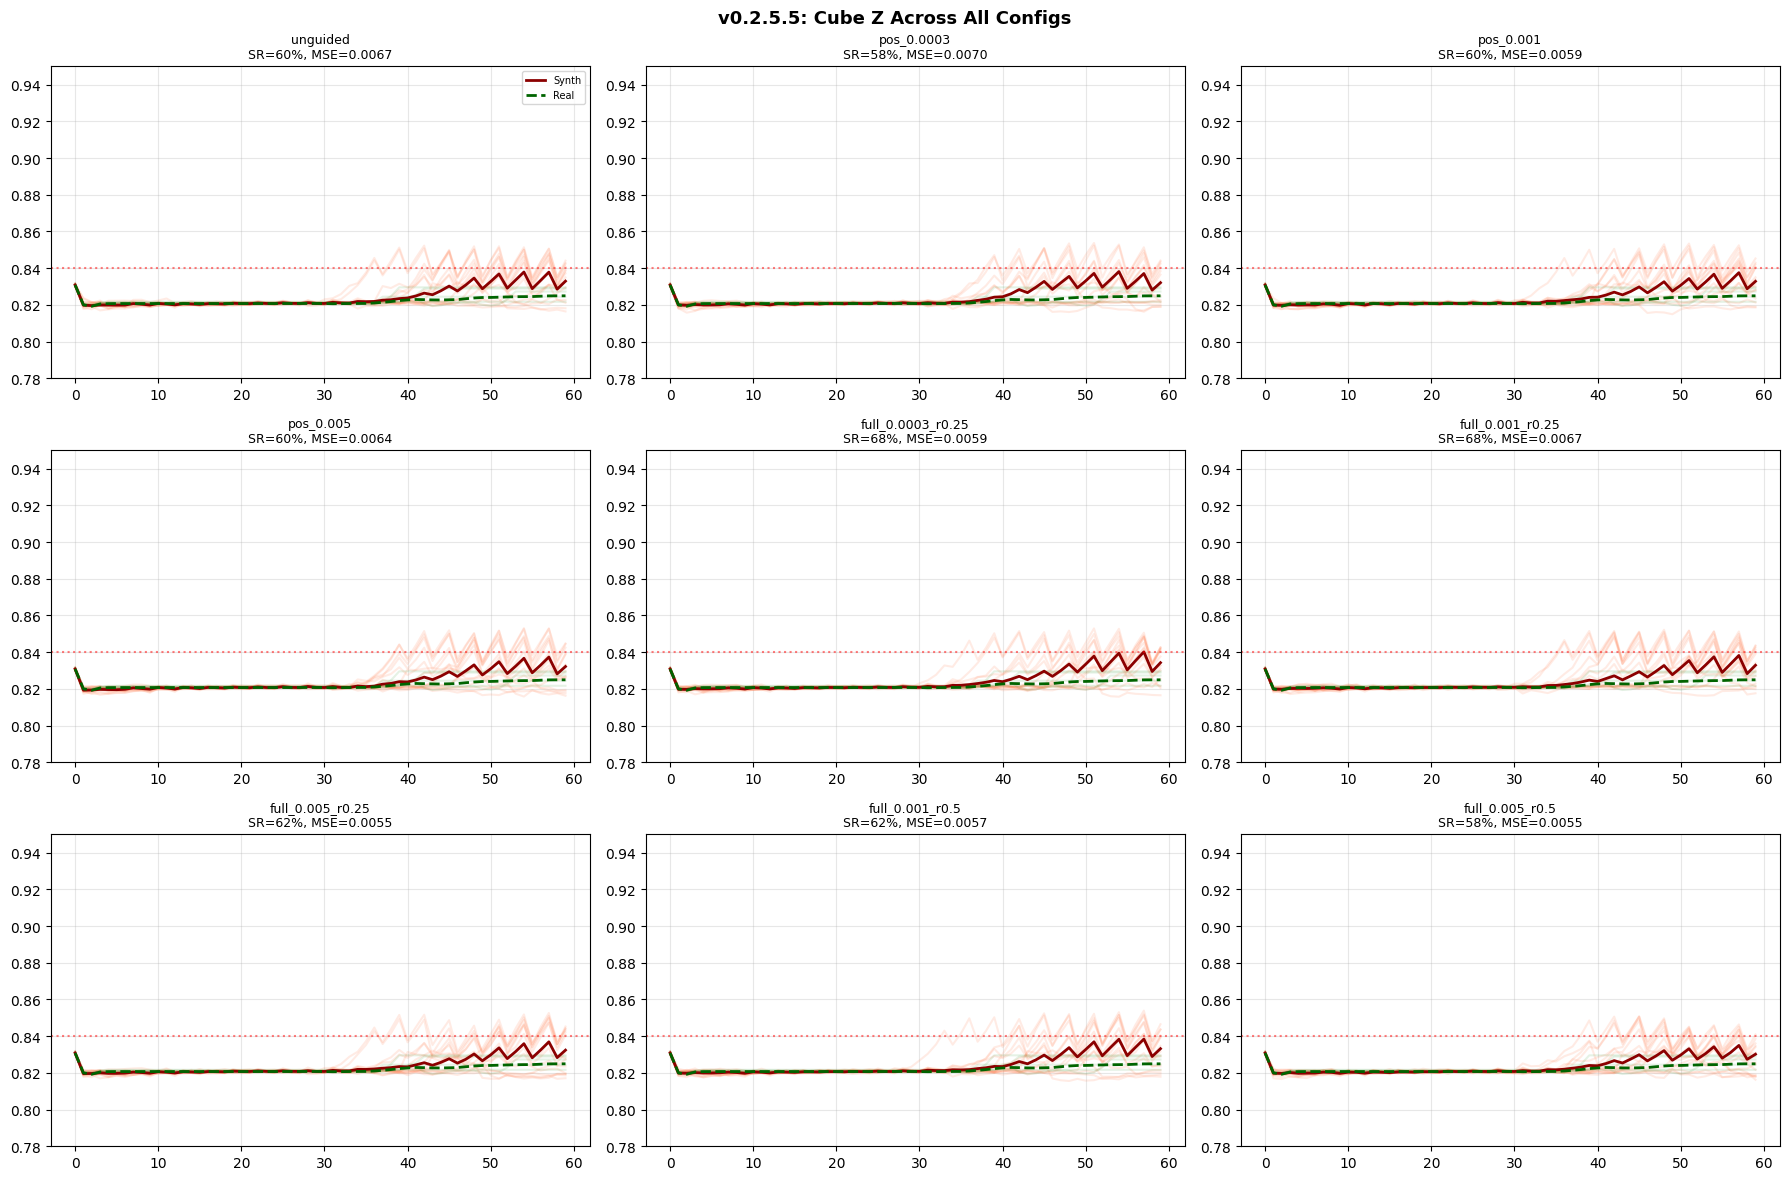

In [9]:
# ── Figure 2: Cube z grid ──
n_configs = len(results)
n_cols = 3
n_rows = math.ceil(n_configs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, (label, r) in enumerate(results.items()):
    ax = axes[idx]
    ss = r["synth_states"]
    for j in range(min(15, N_COMPARE)):
        ax.plot(ss[j, :, CUBE_Z_INDEX], color="coral", alpha=0.15)
    for j in range(min(5, N_COMPARE)):
        ax.plot(real_states[j, :, CUBE_Z_INDEX], color="green", alpha=0.1)
    ax.plot(ss[:, :, CUBE_Z_INDEX].mean(0), color="darkred", lw=2, label="Synth")
    ax.plot(real_states[:, :, CUBE_Z_INDEX].mean(0), color="darkgreen", lw=2, ls="--", label="Real")
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_title(f"{label}\nSR={r['synth_sr']*100:.0f}%, MSE={r['state_mse']:.4f}", fontsize=9)
    ax.set_ylim([0.78, 0.95])
    ax.grid(True, alpha=0.3)
    if idx == 0: ax.legend(fontsize=7)

for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("v0.2.5.5: Cube Z Across All Configs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

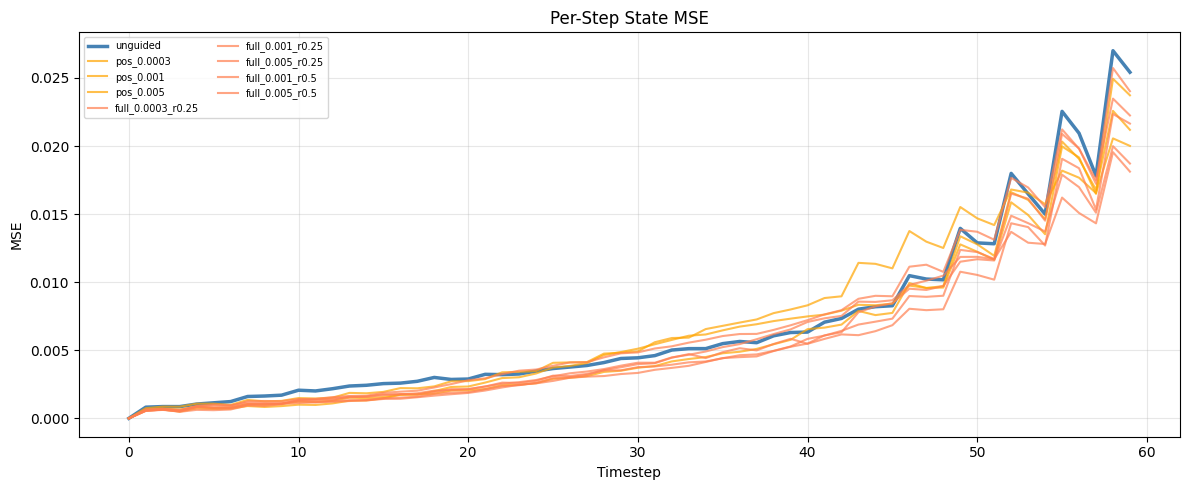

In [10]:
# ── Figure 3: Per-step MSE ──
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
for label, r in results.items():
    color = "steelblue" if "unguided" in label else ("orange" if "pos" in label else "coral")
    lw = 2.5 if "unguided" in label else 1.5
    alpha = 1.0 if "unguided" in label else 0.7
    ax.plot(r["per_step_mse"], label=label, color=color, lw=lw, alpha=alpha)
ax.set_xlabel("Timestep")
ax.set_ylabel("MSE")
ax.set_title("Per-Step State MSE")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

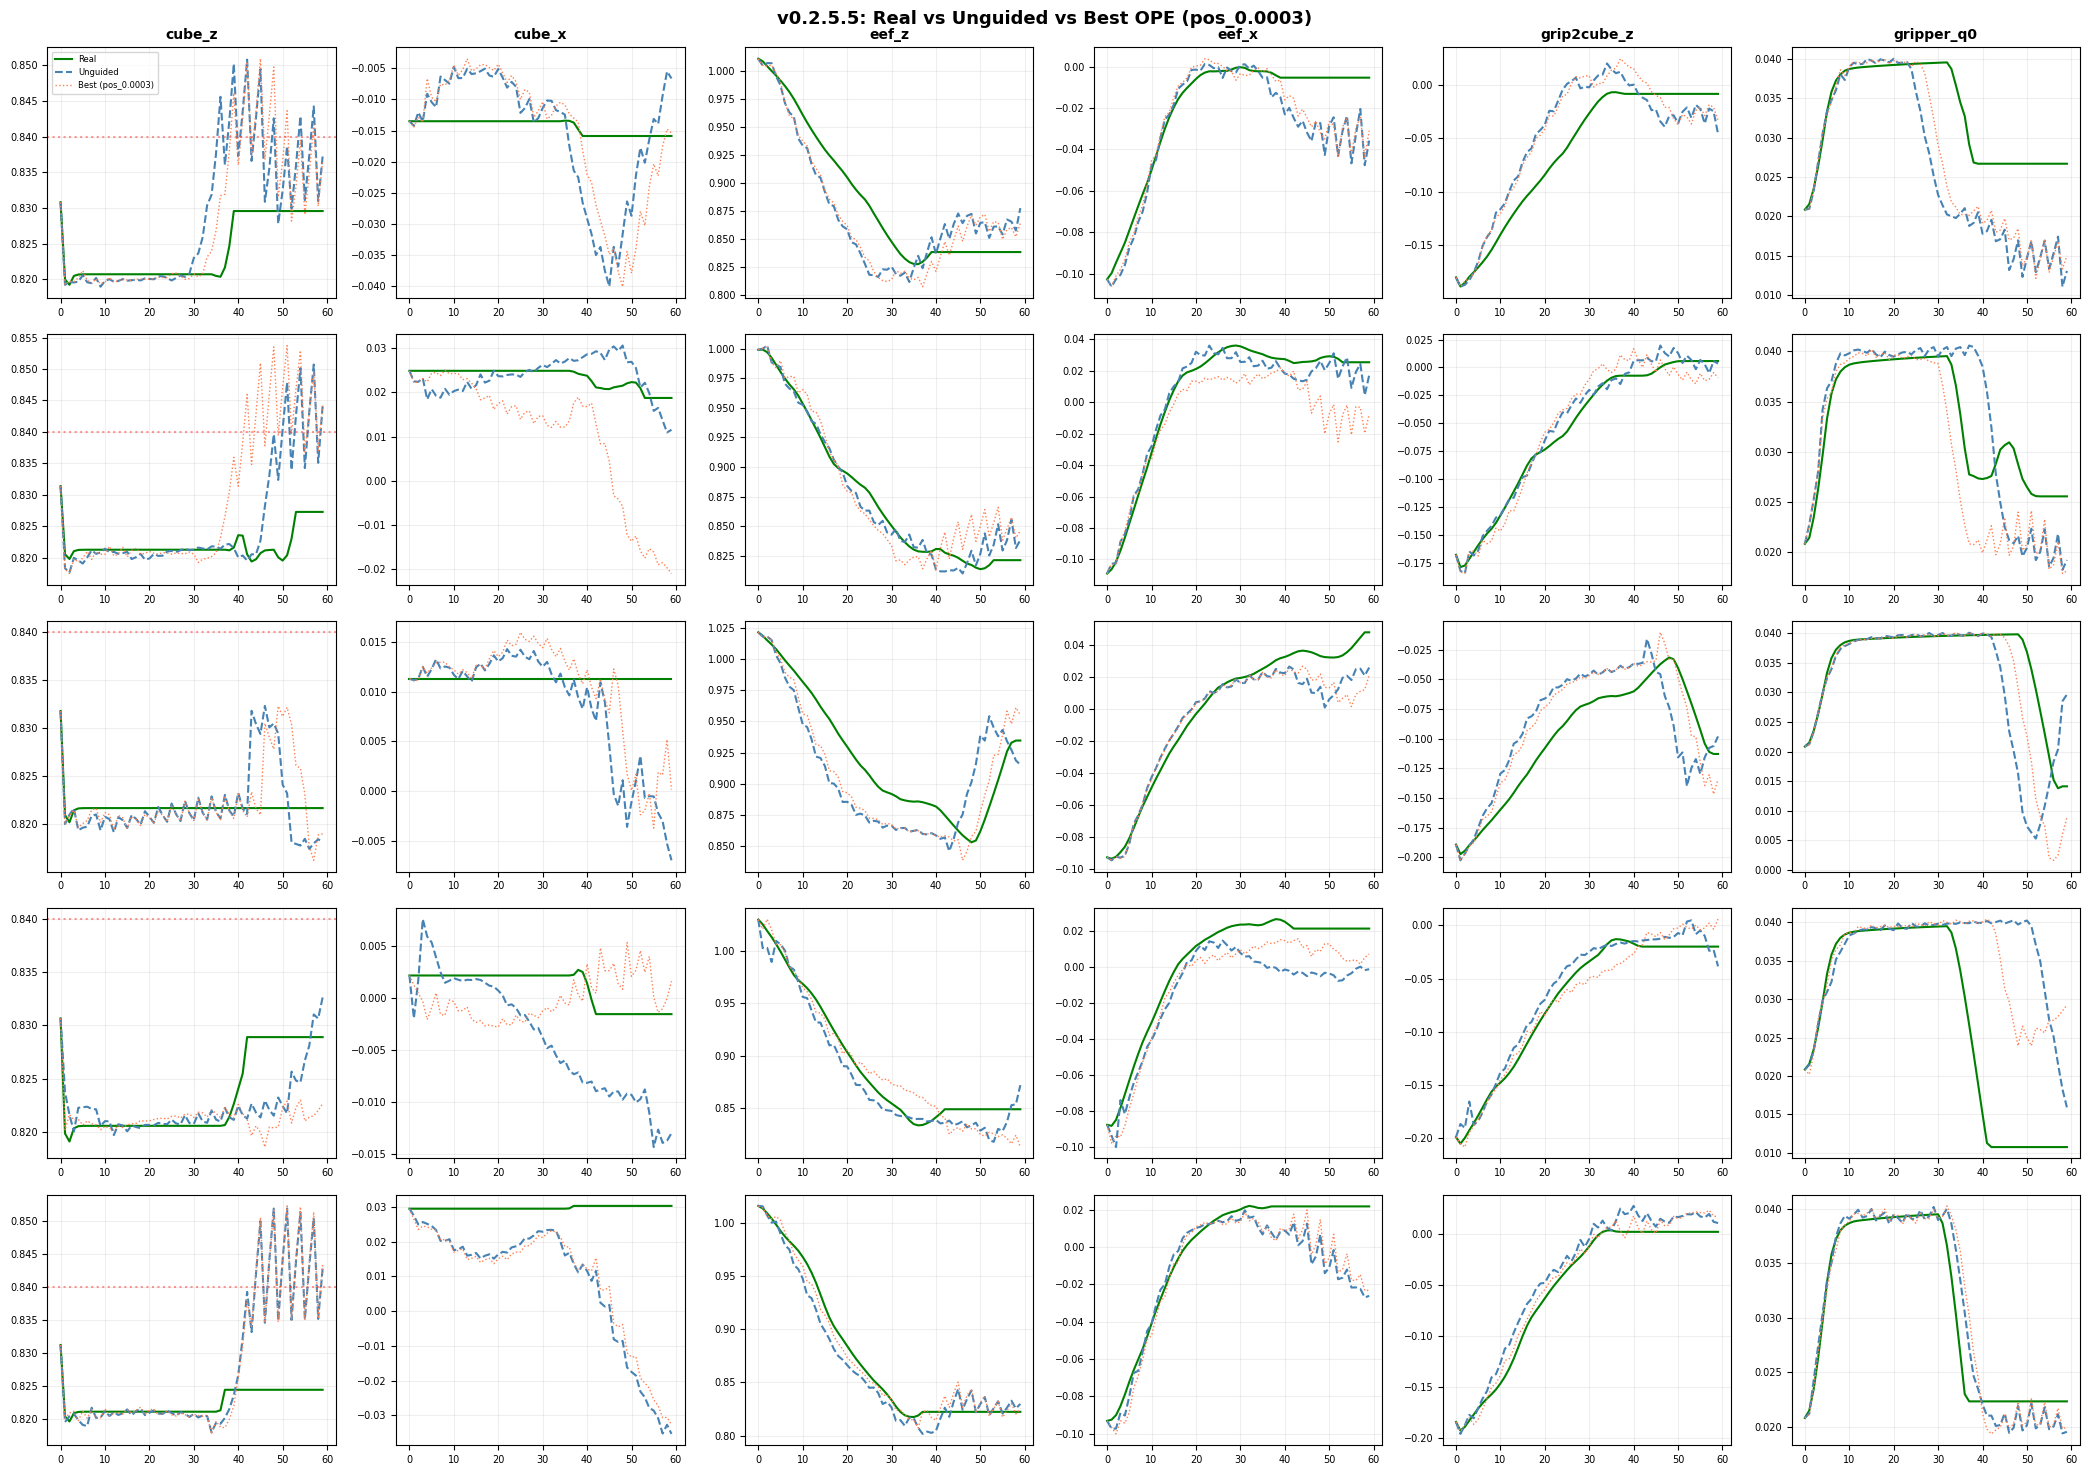

In [11]:
# ── Figure 4: Individual trajectory comparison (5 trajs, key dims) ──
best_label = best_ope
unguided_ss = results["unguided"]["synth_states"]
best_ss = results[best_label]["synth_states"]

KEY_DIMS = {"cube_z": 2, "cube_x": 0, "eef_z": 12, "eef_x": 10, "grip2cube_z": 9, "gripper_q0": 17}
N_SHOW = 5

fig, axes = plt.subplots(N_SHOW, len(KEY_DIMS), figsize=(3.5*len(KEY_DIMS), 3*N_SHOW))
for row in range(N_SHOW):
    for col, (name, dim) in enumerate(KEY_DIMS.items()):
        ax = axes[row, col]
        ax.plot(real_states[row, :, dim], color="green", lw=1.5,
                label="Real" if col==0 and row==0 else "")
        ax.plot(unguided_ss[row, :, dim], color="steelblue", lw=1.5, ls="--",
                label="Unguided" if col==0 and row==0 else "")
        ax.plot(best_ss[row, :, dim], color="coral", lw=1.0, ls=":",
                label=f"Best ({best_label})" if col==0 and row==0 else "")
        if dim == CUBE_Z_INDEX:
            ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.4)
        if row == 0: ax.set_title(name, fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0: ax.legend(fontsize=6)

plt.suptitle(f"v0.2.5.5: Real vs Unguided vs Best OPE ({best_label})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

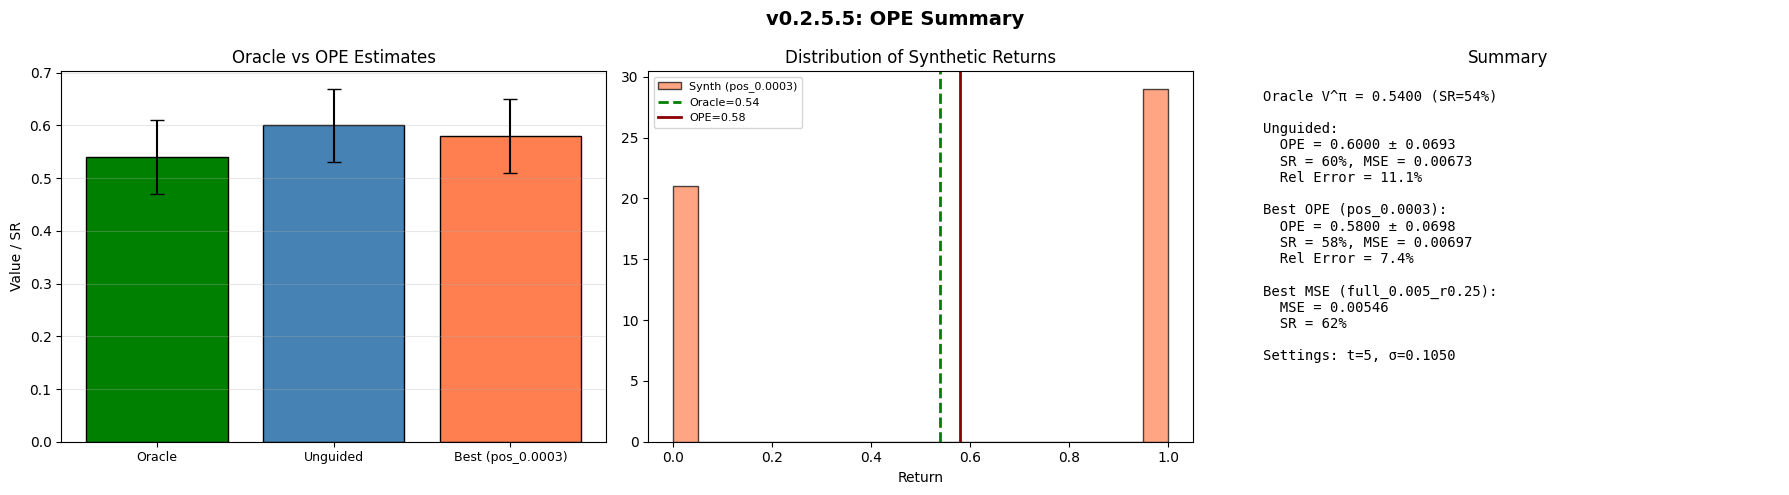

In [12]:
# ── Figure 5: OPE summary ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Oracle vs best OPE bar
ax = axes[0]
br = results[best_ope]
ur = results["unguided"]
x = [0, 1, 2]
vals = [oracle_value, ur["ope_estimate"], br["ope_estimate"]]
errs = [np.std(oracle_returns)/np.sqrt(len(oracle_returns)), ur["ope_std"], br["ope_std"]]
bars = ax.bar(x, vals, yerr=errs, color=["green", "steelblue", "coral"],
              edgecolor="black", capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(["Oracle", "Unguided", f"Best ({best_ope})"], fontsize=9)
ax.set_ylabel("Value / SR")
ax.set_title("Oracle vs OPE Estimates")
ax.grid(True, alpha=0.3, axis="y")

# Panel 2: Histogram of synthetic returns (best config)
ax = axes[1]
ax.hist(br["synth_returns"], bins=20, color="coral", edgecolor="black", alpha=0.7, label=f"Synth ({best_ope})")
ax.axvline(x=oracle_value, color="green", lw=2, ls="--", label=f"Oracle={oracle_value:.2f}")
ax.axvline(x=br["ope_estimate"], color="darkred", lw=2, ls="-", label=f"OPE={br['ope_estimate']:.2f}")
ax.set_xlabel("Return")
ax.set_title("Distribution of Synthetic Returns")
ax.legend(fontsize=8)

# Panel 3: Text summary
ax = axes[2]
ax.axis("off")
summary = [
    f"Oracle V^π = {oracle_value:.4f} (SR={oracle_sr*100:.0f}%)",
    f"",
    f"Unguided:",
    f"  OPE = {ur['ope_estimate']:.4f} ± {ur['ope_std']:.4f}",
    f"  SR = {ur['synth_sr']*100:.0f}%, MSE = {ur['state_mse']:.5f}",
    f"  Rel Error = {ur['ope_rel_err']*100:.1f}%",
    f"",
    f"Best OPE ({best_ope}):",
    f"  OPE = {br['ope_estimate']:.4f} ± {br['ope_std']:.4f}",
    f"  SR = {br['synth_sr']*100:.0f}%, MSE = {br['state_mse']:.5f}",
    f"  Rel Error = {br['ope_rel_err']*100:.1f}%",
    f"",
    f"Best MSE ({best_mse}):",
    f"  MSE = {results[best_mse]['state_mse']:.5f}",
    f"  SR = {results[best_mse]['synth_sr']*100:.0f}%",
    f"",
    f"Settings: t={SCORE_TIMESTEP}, σ={target_scorer.sigma:.4f}",
]
ax.text(0.05, 0.95, "\n".join(summary), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
ax.set_title("Summary")

plt.suptitle("v0.2.5.5: OPE Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()